In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

| Category | Feature Name | Description | Key Insight for Analysis |
| :--- | :--- | :--- | :--- |
| **Identifiers** | `date` | Date of the Close Approach. | One asteroid can have multiple entries (multiple passes). |
| | `id` | Unique NASA JPL identifier. | Use this to filter for unique objects vs. unique events. |
| | `name` | Scientific designation (e.g., "2010 FR"). | Used for labeling and referencing specific rocks. |
| **Physical Stats** | `absolute_magnitude_h` | Measure of intrinsic brightness. | **Inversion:** Lower values = larger, brighter asteroids. |
| | `est_diameter_min_km` | Minimum estimated size. | Critical for hazard prediction; usually a range. |
| | `est_diameter_max_km` | Maximum estimated size. | Larger diameters = higher potential kinetic energy. |
| **Motion** | `relative_velocity_kmh` | Speed relative to Earth at approach. | Higher speeds indicate higher impact energy. |
| | `miss_distance_km` | Distance from Earth's center. | Comparison: The Moon is ~384,400 km away. |
| **Target** | `is_hazardous` | Boolean (True/False). | The label to predict. Based on size and proximity. |

In [81]:
df = pd.read_csv("nasa_asteroid_data_2_years.csv")
df

,date,id,name,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,relative_velocity_kmh,miss_distance_km,is_potentially_hazardous
0,2023-10-01,2252399,252399 (2001 TX44),19.41,0.348783,0.779902,47425.552833,6.212955e+07,True
1,2023-10-01,3342645,(2006 SG7),22.84,0.071871,0.160709,40346.826106,4.884087e+07,False
2,2023-10-01,3451020,(2009 EG3),21.31,0.145397,0.325117,71098.010905,2.010022e+07,False
3,2023-10-01,3606252,(2012 OO),20.64,0.197950,0.442629,33991.729171,2.520877e+07,True
4,2023-10-01,3740047,(2016 AM165),24.70,0.030518,0.068240,21746.721909,6.950319e+07,False
...,...,...,...,...,...,...,...,...,...
13420,2025-06-16,54527891,(2025 HN6),25.93,0.017320,0.038729,8190.911862,2.437709e+06,False
13421,2025-06-16,54534335,(2025 LL),22.16,0.098300,0.219806,46497.474574,1.802311e+07,False
13422,2025-06-16,54534882,(2025 MG),27.96,0.006801,0.015207,106181.652877,4.135562e+05,False
13423,2025-06-16,54534885,(2025 MJ),24.87,0.028220,0.063102,29803.912911,4.599583e+06,False


In [82]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 13425 entries, 0 to 13424
Data columns (total 9 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   date                       13425 non-null  object 
 1   id                         13425 non-null  int64  
 2   name                       13425 non-null  object 
 3   absolute_magnitude_h       13425 non-null  float64
 4   estimated_diameter_min_km  13425 non-null  float64
 5   estimated_diameter_max_km  13425 non-null  float64
 6   relative_velocity_kmh      13425 non-null  float64
 7   miss_distance_km           13425 non-null  float64
 8   is_potentially_hazardous   13425 non-null  bool   
dtypes: bool(1), float64(5), int64(1), object(2)
memory usage: 852.3+ KB


In [83]:
df.describe()

,id,absolute_magnitude_h,estimated_diameter_min_km,estimated_diameter_max_km,relative_velocity_kmh,miss_distance_km
count,1.342500e+04,13425.000000,13425.000000,13425.000000,13425.000000,1.342500e+04
mean,3.942811e+07,24.743238,0.061479,0.137470,44275.459314,2.793989e+07
std,2.319009e+07,2.479516,0.118928,0.265931,23322.475031,2.278491e+07
min,2.000887e+06,13.820000,0.000799,0.001787,1418.218469,7.726027e+03
25%,3.837806e+06,23.230000,0.013445,0.030064,26959.488021,7.132264e+06
50%,5.439066e+07,24.950000,0.027199,0.060819,39840.502121,2.270063e+07
75%,5.446903e+07,26.480000,0.060056,0.134289,57860.728392,4.718536e+07
max,5.460724e+07,32.610000,4.576727,10.233872,190513.420686,7.479169e+07


In [84]:
df.describe(exclude="number")

,date,name,is_potentially_hazardous
count,13425,13425,13425
unique,625,9485,2
top,2023-10-13,(2022 GT3),False
freq,78,6,12782


In [85]:
if df.duplicated().sum() > 0:
    print(f"Dropping {df.duplicated().sum()} data duplicates...")
    duplicate_value_df = df.duplicated()
    df = df.drop_duplicates()

Dropping 1907 data duplicates...


# EDA

Hazardous Potential (0): 95.25959367945825%
Hazardous Potential (1): 4.740406320541761%


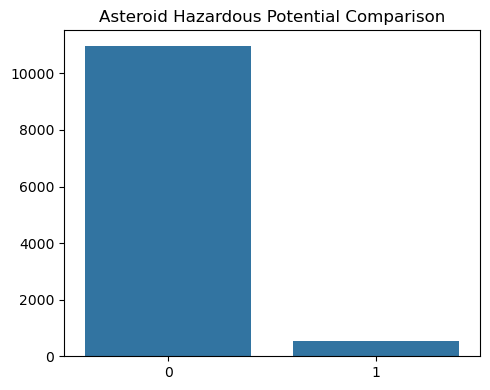

In [100]:
hazardous_distribution = df['is_potentially_hazardous'].value_counts()

print(f"Hazardous Potential (0): {hazardous_distribution.values[0]/df.shape[0] * 100}%")
print(f"Hazardous Potential (1): {hazardous_distribution.values[1]/df.shape[0] * 100}%")

plt.figure(figsize=(5, 4))
ax = sns.barplot(
    x=list(hazardous_distribution.keys()),
    y=list(hazardous_distribution.values),
)
plt.title("Asteroid Hazardous Potential Comparison")
plt.tight_layout()
plt.show()

In [95]:
hazardous_distribution.values[0]

np.int64(10972)

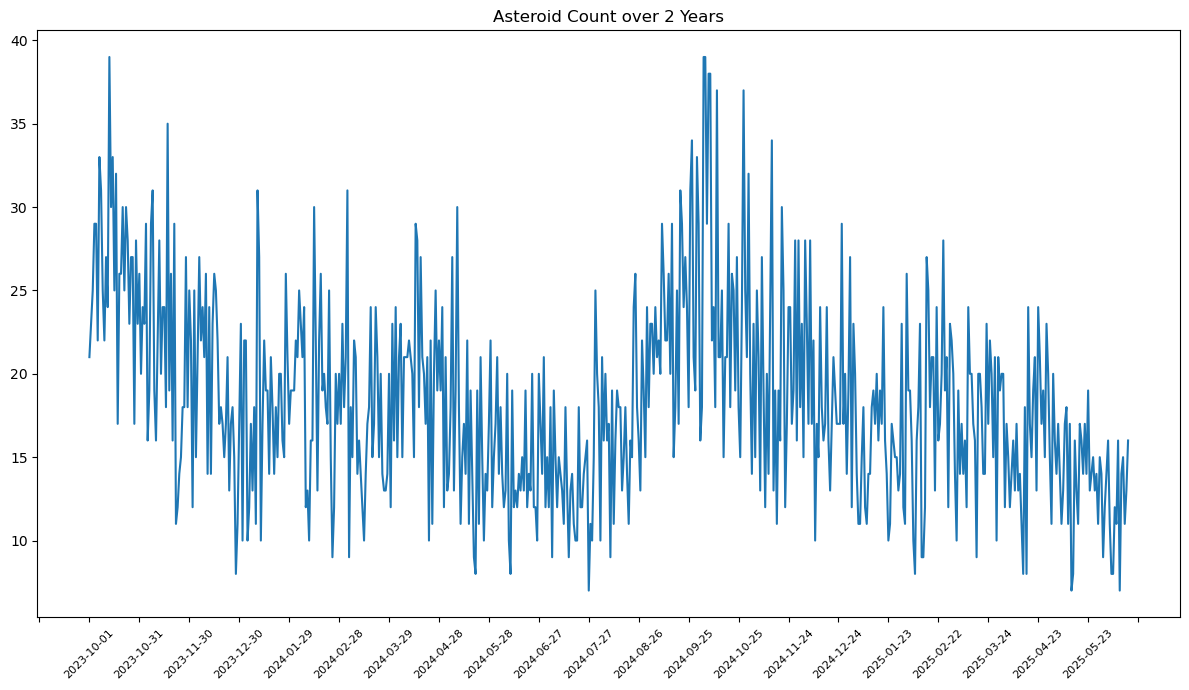

In [86]:
import matplotlib.ticker as ticker

date_distribution = df['date'].value_counts().sort_index()

plt.figure(figsize=(12, 7))
ax = sns.lineplot(
    x=list(date_distribution.keys()),
    y=list(date_distribution.values),
)
ax.xaxis.set_major_locator(ticker.MaxNLocator(26))
plt.xticks(rotation=45, fontsize=8)
plt.title("Asteroid Count over 2 Years")
plt.tight_layout()
plt.show()

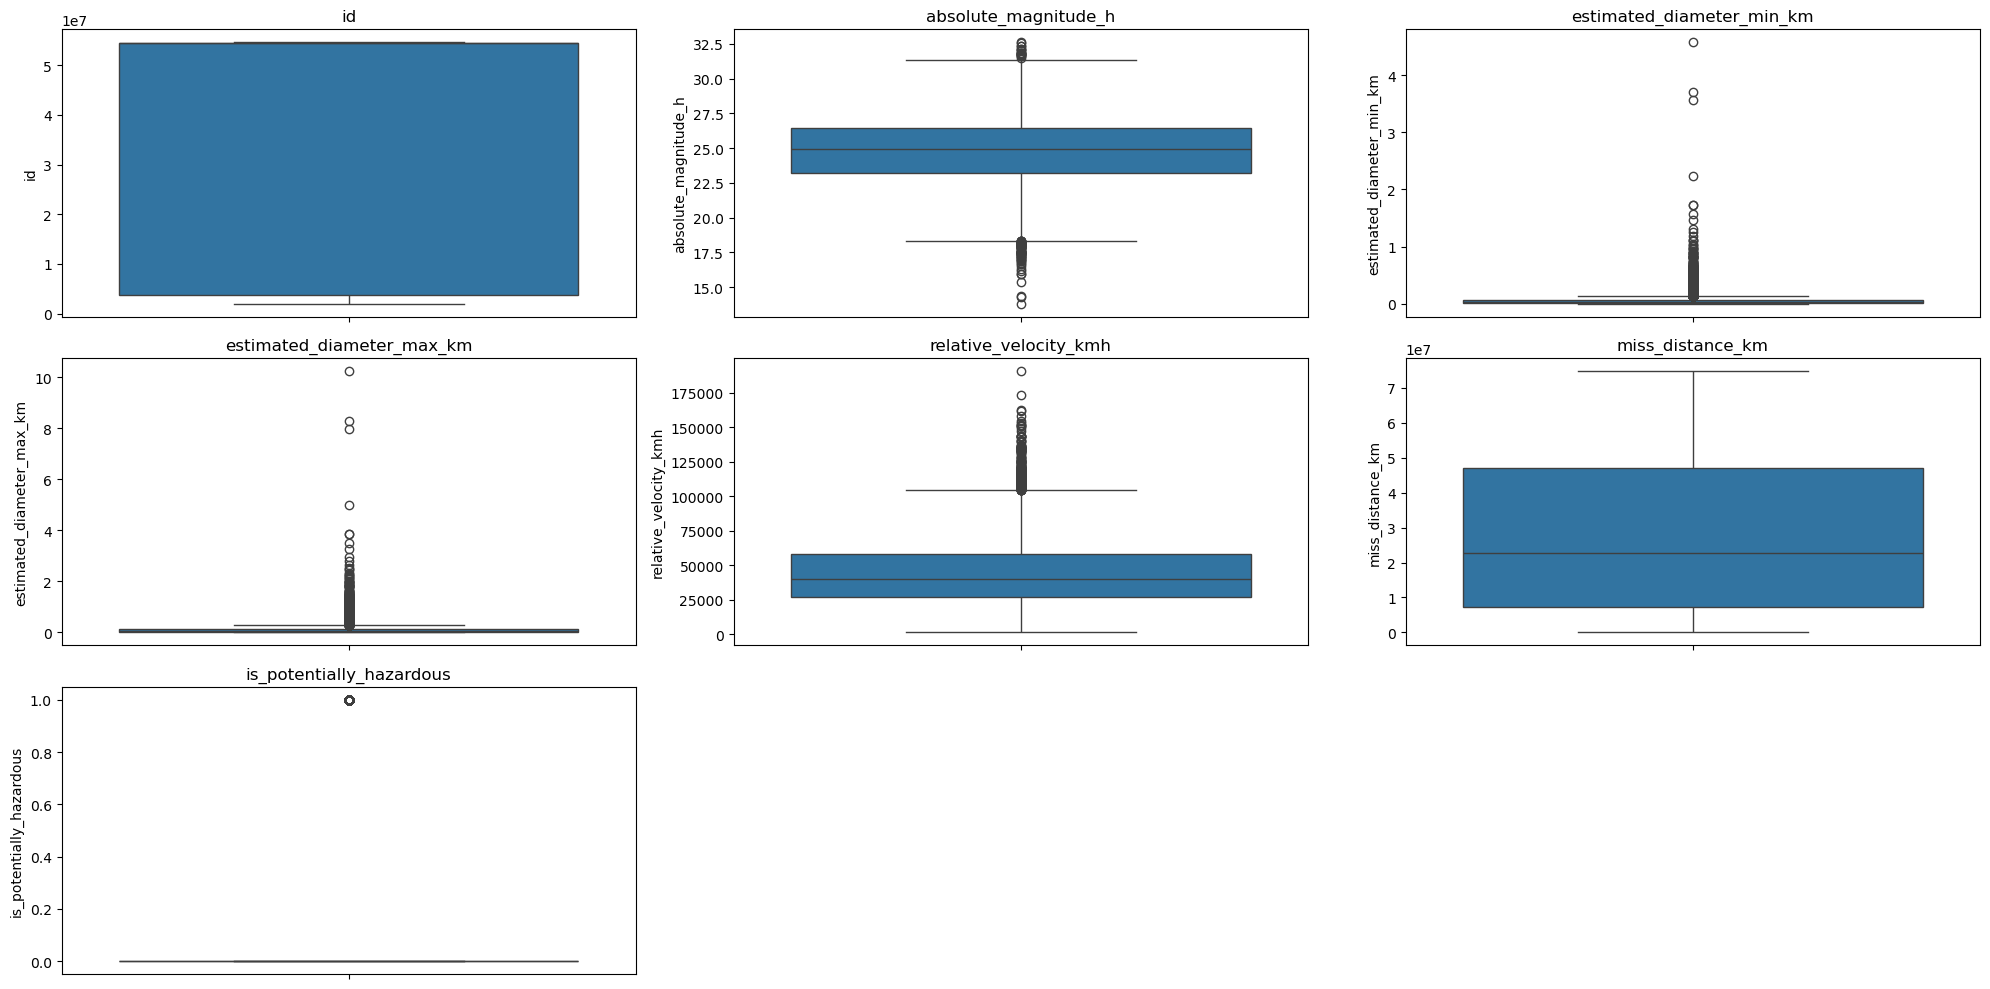

In [110]:
numerical_cols = df.select_dtypes(include=np.number)
plt.figure(figsize=(20,10))
for idx, col in enumerate(numerical_cols):
  plt.subplot(3,3,idx+1)
  sns.boxplot(df[col])
  plt.title(col)
plt.tight_layout()

C:\Users\benma\AppData\Local\Temp\ipykernel_13740\4223507086.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['is_potentially_hazardous'] = df['is_potentially_hazardous'].astype('int')


<Axes: >

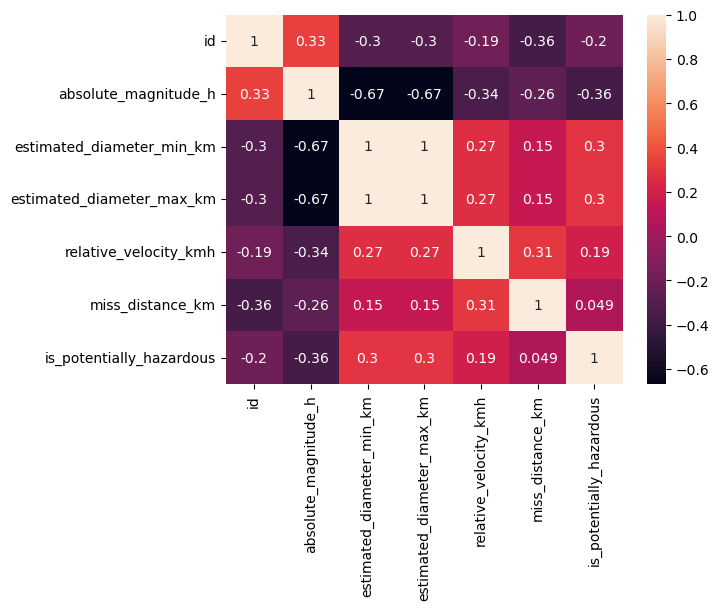

In [87]:
df['is_potentially_hazardous'] = df['is_potentially_hazardous'].astype('int')
corr = df.corr(numeric_only=True)
sns.heatmap(
    corr,
    annot=True
)

**Insights:**
- A **0.49 correlation** between `miss_distance_km` and `is_potentially_hazardous` might still mean something since the NASA rule for an asteroid to be flagged as is_potentially_hazardous to be True, it must meet both of these conditions:
    - It must come within 0.05 Astronomical Units (about 7.5 million km) of Earth.
    - It must be a certain size (an Absolute Magnitude of 22.0 or less, which is roughly 140 meters across).
- A **1 correlation** between `estimated_diameter_min_km` and `estimated_diameter_min_km` means they are predictable, which means that we don't need both columns as they might introduce **multicolinearity** and **slows down model training**. The predictability comes from NASA using a fixed mathematical formula.
- The correlationg between `absolute_magnitude_h` and the `estimated_diameter_min_max_km` shows that the less H, means the bigger estimated diameter size. In other words, **more light (less H), the bigger the asteroid.**
- With an average of **0.15 - 0.3 correlation**, this can be really helpful to train the model since we are dealing with anomaly detection.

In [104]:
cleaned_df = df.drop(['date', 'id', 'name', 'estimated_diameter_min_km'], axis=1)
cleaned_df

,absolute_magnitude_h,estimated_diameter_max_km,relative_velocity_kmh,miss_distance_km,is_potentially_hazardous
0,19.41,0.779902,47425.552833,6.212955e+07,1
1,22.84,0.160709,40346.826106,4.884087e+07,0
2,21.31,0.325117,71098.010905,2.010022e+07,0
3,20.64,0.442629,33991.729171,2.520877e+07,1
4,24.70,0.068240,21746.721909,6.950319e+07,0
...,...,...,...,...,...
13420,25.93,0.038729,8190.911862,2.437709e+06,0
13421,22.16,0.219806,46497.474574,1.802311e+07,0
13422,27.96,0.015207,106181.652877,4.135562e+05,0
13423,24.87,0.063102,29803.912911,4.599583e+06,0


# Modelling Preperation

In [115]:
from sklearn.model_selection import train_test_split

X = cleaned_df.drop(['is_potentially_hazardous'], axis=1)
y = cleaned_df['is_potentially_hazardous']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

X_train.shape, X_test.shape, y_train.shape, y_test.shape

((9214, 4), (2304, 4), (9214,), (2304,))

In [116]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train[X.columns]), columns=X.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test[X.columns]), columns=X.columns)

X_train_scaled

,absolute_magnitude_h,estimated_diameter_max_km,relative_velocity_kmh,miss_distance_km
0,-0.266154,0.286216,1.129563,0.581730
1,-0.216923,0.224339,0.262176,-0.315757
2,0.724615,-0.387154,-0.073716,0.268144
3,1.521538,-0.524893,-0.974876,-0.112850
4,0.924615,-0.438304,-0.374914,-0.560774
...,...,...,...,...
9209,-0.543077,0.733578,-0.484613,-0.047242
9210,0.001538,-0.001347,0.057505,-0.467949
9211,-0.380000,0.448039,-0.184643,0.674611
9212,-0.598462,0.847526,1.820664,1.029275


In [118]:
scale_pos_weight_value = y_train.value_counts()[0] / y_train.value_counts()[1]
scale_pos_weight_value

np.float64(20.08466819221968)

In [119]:
import optuna
import mlflow
import mlflow.sklearn
import mlflow.xgboost
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score, f1_score, accuracy_score

mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Asteroid_Hazard_Prediction")

c:\Users\benma\anaconda3\envs\deep_learning\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026/03/31 14:50:32 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/03/31 14:50:32 INFO mlflow.store.db.utils: Updating database tables
2026/03/31 14:50:32 INFO mlflow.tracking.fluent: Experiment with name 'Asteroid_Hazard_Prediction' does not exist. Creating a new experiment.


<Experiment: artifact_location='file:d:/BINUS/Portfolio Projects/asteroid-detection/mlruns/1', creation_time=1774943432996, experiment_id='1', last_update_time=1774943432996, lifecycle_stage='active', name='Asteroid_Hazard_Prediction', tags={}, workspace='default'>

In [120]:
def objective(trial):
    with mlflow.start_run(nested=True):
        
        classifier_name = trial.suggest_categorical("classifier", ["DecisionTree", "RandomForest", "XGBoost"])
        
        if classifier_name == "DecisionTree":
            max_depth = trial.suggest_int("dt_max_depth", 2, 20)
            model = DecisionTreeClassifier(max_depth=max_depth, class_weight="balanced", random_state=42)
            
        elif classifier_name == "RandomForest":
            n_estimators = trial.suggest_int("rf_n_estimators", 50, 300)
            max_depth = trial.suggest_int("rf_max_depth", 2, 20)
            model = RandomForestClassifier(n_estimators=n_estimators, max_depth=max_depth, class_weight="balanced", random_state=42)
            
        else:
            n_estimators = trial.suggest_int("xgb_n_estimators", 50, 300)
            learning_rate = trial.suggest_float("xgb_learning_rate", 0.01, 0.3)
            max_depth = trial.suggest_int("xgb_max_depth", 2, 10)
            model = XGBClassifier(
                n_estimators=n_estimators, 
                learning_rate=learning_rate, 
                max_depth=max_depth,
                scale_pos_weight=scale_pos_weight_value,
                random_state=42,
                use_label_encoder=False,
                eval_metric="logloss"
            )

        mlflow.log_params(trial.params)
        mlflow.log_param("classifier", classifier_name)

        model.fit(X_train, y_train)
        preds = model.predict(X_test)

        # We care most about catching dangerous asteroids, so Recall for class 1 is our main metric
        recall = recall_score(y_test, preds)
        f1 = f1_score(y_test, preds)
        accuracy = accuracy_score(y_test, preds)

        mlflow.log_metric("recall", recall)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("accuracy", accuracy)

        if classifier_name == "XGBoost":
            mlflow.xgboost.log_model(model, "model")
        else:
            mlflow.sklearn.log_model(model, "model")

        return recall

print("Starting Optuna search...")
study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=30) 

print("\nBest Trial:")
print(f"  Recall Score: {study.best_value}")
print(f"  Params: {study.best_params}")

[I 2026-03-31 14:52:21,872] A new study created in memory with name: no-name-741669e9-272f-4b40-bb1d-f1b2bf5a4aff


Starting Optuna search...


c:\Users\benma\anaconda3\envs\deep_learning\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:52:23] WARNING: D:\bld\xgboost-split_1738880170463\work\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
2026/03/31 14:52:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
[I 2026-03-31 14:52:32,666] Trial 0 finished with value: 0.6788990825688074 and parameters: {'classifier': 'XGBoost', 'xgb_n_estimators': 94, 'xgb_learning_rate': 0.23070230635864467, 'xgb_max_depth': 7}. Best is trial 0 with value: 0.6788990825688074.
2026/03/31 14:52:33 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 14:52:33 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The rec


Best Trial:
  Recall Score: 0.9908256880733946
  Params: {'classifier': 'RandomForest', 'rf_n_estimators': 289, 'rf_max_depth': 2}


In [123]:
import torch
import torch.nn as nn
import joblib
import mlflow.pytorch

class AsteroidAutoencoder(nn.Module):
    def __init__(self):
        super(AsteroidAutoencoder, self).__init__()
        
        # The Encoder: Compresses 4 features down to 2
        self.encoder = nn.Sequential(
            nn.Linear(4, 3),
            nn.ReLU(),
            nn.Linear(3, 2) # The Bottleneck
        )
        
        # The Decoder: Decompresses 2 features back to 4
        self.decoder = nn.Sequential(
            nn.Linear(2, 3),
            nn.ReLU(),
            nn.Linear(3, 4)
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return decoded

model = AsteroidAutoencoder()
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

In [122]:
safe_asteroids = cleaned_df[cleaned_df['is_potentially_hazardous'] == 0][X.columns]
hazard_asteroids = cleaned_df[cleaned_df['is_potentially_hazardous'] == 1][X.columns]

X_train_safe, X_test_safe = train_test_split(safe_asteroids, test_size=0.2, random_state=42)

scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train_safe)

X_train_tensor = torch.FloatTensor(X_train_scaled)

In [ ]:
mlflow.set_tracking_uri("sqlite:///mlflow.db")
mlflow.set_experiment("Asteroid_Hazard_Prediction")

print("Starting training and MLflow logging...")

with mlflow.start_run(run_name="PyTorch_Autoencoder_Anomaly_Detector"):
    
    epochs = 200
    
    for epoch in range(epochs):
        reconstructed = model(X_train_tensor)
        loss = criterion(reconstructed, X_train_tensor)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    
    X_test_safe_scaled = scaler.transform(X_test_safe)
    X_test_hazard_scaled = scaler.transform(hazard_asteroids)

    safe_tensor = torch.FloatTensor(X_test_safe_scaled)
    hazard_tensor = torch.FloatTensor(X_test_hazard_scaled)
    
    # --- EVALUATION & THRESHOLDING ---
    model.eval()
    with torch.no_grad():
        safe_reconstruction = model(safe_tensor)
        hazard_reconstruction = model(hazard_tensor)
        
        safe_errors = torch.mean((safe_reconstruction - safe_tensor)**2, dim=1).numpy()
        hazard_errors = torch.mean((hazard_reconstruction - hazard_tensor)**2, dim=1).numpy()

    threshold = np.percentile(safe_errors, 95)
    
    # --- TRANSLATING ERRORS TO OFFICIAL METRICS ---
    y_true_safe = np.zeros(len(safe_errors))
    y_true_hazard = np.ones(len(hazard_errors))
    y_true_combined = np.concatenate([y_true_safe, y_true_hazard])
    
    y_pred_safe = (safe_errors > threshold).astype(int)
    y_pred_hazard = (hazard_errors > threshold).astype(int)
    y_pred_combined = np.concatenate([y_pred_safe, y_pred_hazard])
    
    final_recall = recall_score(y_true_combined, y_pred_combined)
    final_f1 = f1_score(y_true_combined, y_pred_combined)
    
    # --- LOGGING EVERYTHING TO MLFLOW ---
    mlflow.log_param("classifier", "Autoencoder")
    mlflow.log_param("epochs", epochs)
    mlflow.log_param("threshold", threshold)
    
    mlflow.log_metric("recall", final_recall)
    mlflow.log_metric("f1_score", final_f1)
    
    mlflow.pytorch.log_model(model, "pytorch_model")
    
    joblib.dump(scaler, "robust_scaler.pkl")
    mlflow.log_artifact("robust_scaler.pkl", "scaler_directory")

    print(f"\nSuccessfully logged to MLflow!")
    print(f"Autoencoder Recall: {final_recall:.4f}")
    print(f"Autoencoder F1: {final_f1:.4f}")

Starting training and MLflow logging...


2026/03/31 15:08:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/03/31 15:08:19 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization.The recommended safe alternative is to set 'export_model' to True to save the pytorch model using the safe graph model format.
2026/03/31 15:08:20 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu126) contains a local version label (+cu126). MLflow logged a pip requirement for this package as 'torch==2.6.0' without the local version label to make it installable from PyPI. To specify pip requirements containing local version labels, please use `conda_env` or `pip_requirements`.
2026/03/31 15:08:24 WARNING mlflow.utils.requirements_utils: Found torch version (2.6.0+cu126) contains a local version label (+cu126). ML


Successfully logged to MLflow!
Autoencoder Recall: 0.0513
Autoencoder F1: 0.0819
